##LSTM 모델

In [ ]:
import os
import yfinance as yf
import pandas as pd
import numpy as np

# ==========================================
# 1. 10년치 기초 데이터 다운로드 (2015.01 ~ 2025.01)
# ==========================================
def get_raw_data(ticker):
    print(f"[{ticker}] 10년치 데이터 다운로드 중...")
    df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA60'] = df['Close'].rolling(window=60).mean()
    df['Future_Return'] = df['Close'].shift(-20) / df['Close'] - 1

    df.dropna(inplace=True)
    return df

df_spy = get_raw_data('SPY')
df_qqq = get_raw_data('QQQ')

# ==========================================
# 2. 슬라이딩 윈도우 생성 및 완벽한 시계열 분할
# ==========================================
def create_sequences(df, window_size=60):
    X, returns = [], []
    data = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA60']].values
    ret_data = df['Future_Return'].values
    for i in range(len(data) - window_size):
        X.append(data[i : i+window_size])
        returns.append(ret_data[i + window_size - 1])
    return np.array(X), np.array(returns)

X_spy, ret_spy = create_sequences(df_spy)
X_qqq, ret_qqq = create_sequences(df_qqq)

# 🌟 각 종목별로 정확히 80%(Train) / 20%(Test) 분할
split_spy = int(len(X_spy) * 0.8)
split_qqq = int(len(X_qqq) * 0.8)

# Train Set (과거 8년) 통합
X_train_base = np.concatenate((X_spy[:split_spy], X_qqq[:split_qqq]), axis=0)
ret_train_base = np.concatenate((ret_spy[:split_spy], ret_qqq[:split_qqq]), axis=0)

# Test Set (최근 2년) 통합
X_test_base = np.concatenate((X_spy[split_spy:], X_qqq[split_qqq:]), axis=0)
ret_test_base = np.concatenate((ret_spy[split_spy:], ret_qqq[split_qqq:]), axis=0)

print(f"\n✅ 기초 분할 완료! (데이터 누수 완벽 차단)")
print(f"Train Base (8년): {X_train_base.shape[0]}개")
print(f"Test Base (2년): {X_test_base.shape[0]}개")

[SPY] 10년치 데이터 다운로드 중...


/tmp/ipykernel_493/2737725450.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)


[QQQ] 10년치 데이터 다운로드 중...


/tmp/ipykernel_493/2737725450.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)



✅ 기초 분할 완료! (데이터 누수 완벽 차단)
Train Base (8년): 3802개
Test Base (2년): 952개


In [ ]:
# ==========================================
# 전략 1: 노이즈 버리기 (상위 30% vs 하위 30%)
# ==========================================
import os
import numpy as np

os.makedirs('./dataset_strategy_1', exist_ok=True)

# 🌟 기준선(Threshold)은 반드시 Train 데이터에서만 구합니다 (Data Leakage 방지)
p30 = np.percentile(ret_train_base, 30)
p70 = np.percentile(ret_train_base, 70)

# Train 데이터 필터링
idx_tr_c0 = np.where(ret_train_base <= p30)[0]
idx_tr_c1 = np.where(ret_train_base >= p70)[0]
X_s1_tr = np.concatenate((X_train_base[idx_tr_c0], X_train_base[idx_tr_c1]), axis=0)
Y_s1_tr = np.concatenate((np.zeros(len(idx_tr_c0)), np.ones(len(idx_tr_c1))), axis=0)

# Test 데이터 필터링
idx_te_c0 = np.where(ret_test_base <= p30)[0]
idx_te_c1 = np.where(ret_test_base >= p70)[0]
X_s1_te = np.concatenate((X_test_base[idx_te_c0], X_test_base[idx_te_c1]), axis=0)
Y_s1_te = np.concatenate((np.zeros(len(idx_te_c0)), np.ones(len(idx_te_c1))), axis=0)

# 최종 결합 (LSTM 코드에서 80%로 자르면 다시 정확히 Train/Test로 나뉩니다)
X_s1 = np.concatenate((X_s1_tr, X_s1_te), axis=0)
Y_s1 = np.concatenate((Y_s1_tr, Y_s1_te), axis=0)

np.save('./dataset_strategy_1/X_data.npy', X_s1)
np.save('./dataset_strategy_1/Y_data.npy', Y_s1)

print(f"🎯 [Strategy 1] 완료!")
print(f"기준선: {p30*100:.2f}%(하락) / {p70*100:.2f}%(상승)")
print(f"최종 데이터 개수: {len(X_s1)}개 저장됨.")

🎯 [Strategy 1] 완료!
기준선: -0.44%(하락) / 3.62%(상승)
최종 데이터 개수: 2823개 저장됨.


In [ ]:
# ==========================================
# 전략 2: 상대적 3분위수 (하락 33% / 횡보 33% / 상승 33%)
# ==========================================
import os
import numpy as np

os.makedirs('./dataset_strategy_2', exist_ok=True)

# 🌟 Train 데이터 기준으로 3등분(33.3%, 66.7%) 선 도출
p33 = np.percentile(ret_train_base, 33.33)
p66 = np.percentile(ret_train_base, 66.67)

# Train/Test를 원래 순서대로 결합
X_s2 = np.concatenate((X_train_base, X_test_base), axis=0)
ret_all_s2 = np.concatenate((ret_train_base, ret_test_base), axis=0)

# 정답지 생성 (0, 1, 2)
Y_s2 = np.zeros_like(ret_all_s2)
Y_s2[(ret_all_s2 > p33) & (ret_all_s2 <= p66)] = 1
Y_s2[ret_all_s2 > p66] = 2

np.save('./dataset_strategy_2/X_data.npy', X_s2)
np.save('./dataset_strategy_2/Y_data.npy', Y_s2)

print(f"🎯 [Strategy 2] 완료!")
print(f"기준선: 하위 33%({p33*100:.2f}%) / 상위 33%({p66*100:.2f}%)")
print(f"최종 데이터 개수: {len(X_s2)}개 저장됨.")

🎯 [Strategy 2] 완료!
기준선: 하위 33%(0.00%) / 상위 33%(3.32%)
최종 데이터 개수: 4754개 저장됨.


In [ ]:
# ==========================================
# 전략 3: 중앙값 기준 (상위 50% vs 하위 50%)
# ==========================================
import os
import numpy as np

os.makedirs('./dataset_strategy_3', exist_ok=True)

# 🌟 Train 데이터 기준으로 중간값(Median) 도출
median_ret = np.median(ret_train_base)

# Train/Test 원래 순서대로 결합
X_s3 = np.concatenate((X_train_base, X_test_base), axis=0)
ret_all_s3 = np.concatenate((ret_train_base, ret_test_base), axis=0)

# 중간값 기준으로 이진 분류
Y_s3 = np.where(ret_all_s3 >= median_ret, 1, 0)

np.save('./dataset_strategy_3/X_data.npy', X_s3)
np.save('./dataset_strategy_3/Y_data.npy', Y_s3)

print(f"🎯 [Strategy 3] 완료!")
print(f"기준선: 중앙값({median_ret*100:.2f}%)")
print(f"최종 데이터 개수: {len(X_s3)}개 저장됨.")

🎯 [Strategy 3] 완료!
기준선: 중앙값(1.74%)
최종 데이터 개수: 4754개 저장됨.


---


🚀 [Strategy 1 (Extreme 2-Class)] 학습 시작 (Classes: 2)
Epoch 01/40 | Train Acc: 0.5416 | Test Acc: 0.4124
Epoch 10/40 | Train Acc: 0.5872 | Test Acc: 0.5327
Epoch 20/40 | Train Acc: 0.6076 | Test Acc: 0.5327
Epoch 30/40 | Train Acc: 0.7259 | Test Acc: 0.4938
Epoch 40/40 | Train Acc: 0.7755 | Test Acc: 0.4991

🎯 [Strategy 1 (Extreme 2-Class)] 최종 Test Set 예측 분포 진단
  - Class 0: 228개 예측 (40.4%)
  - Class 1: 337개 예측 (59.6%)
  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.

🚀 [Strategy 2 (Tertile 3-Class)] 학습 시작 (Classes: 3)
Epoch 01/40 | Train Acc: 0.4042 | Test Acc: 0.3859
Epoch 10/40 | Train Acc: 0.4473 | Test Acc: 0.3954
Epoch 20/40 | Train Acc: 0.4967 | Test Acc: 0.2965
Epoch 30/40 | Train Acc: 0.5588 | Test Acc: 0.2986
Epoch 40/40 | Train Acc: 0.6584 | Test Acc: 0.3091

🎯 [Strategy 2 (Tertile 3-Class)] 최종 Test Set 예측 분포 진단
  - Class 0: 368개 예측 (38.7%)
  - Class 1: 295개 예측 (31.0%)
  - Class 2: 288개 예측 (30.3%)
  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.

🚀 [Strategy 3 (Median 2-Class)] 학습 시작 (Classes: 

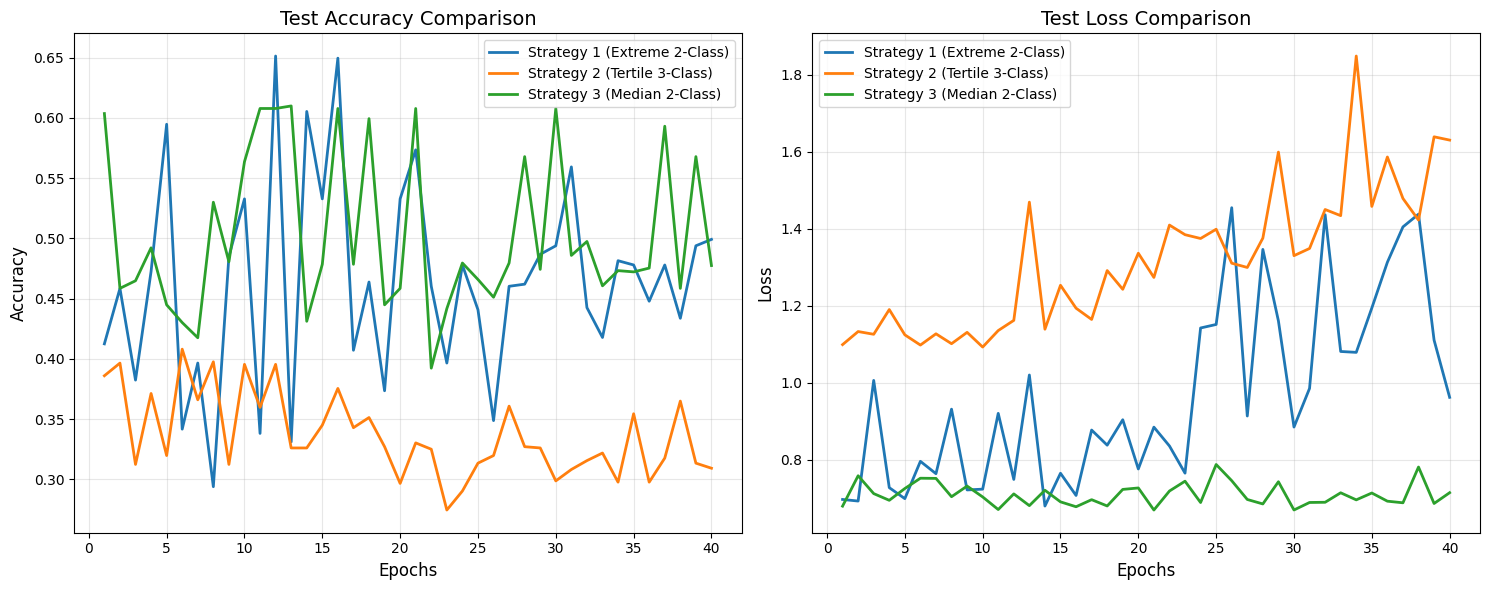

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. Random Seed & 공통 Hyperparameter 세팅
# ==========================================
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.1
LEARNING_RATE = 0.001
EPOCHS = 40
BATCH_SIZE = 64
INPUT_SIZE = 7  # (Open, High, Low, Close, Volume, MA20, MA60)

# ==========================================
# 2. Custom Dataset (가격/거래량 분리 정규화)
# ==========================================
class AdvancedLSTMDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x_seq = self.x[idx].clone()

        # 가격 관련 지표(0,1,2,3,5,6) 묶어서 정규화
        price_indices = [0, 1, 2, 3, 5, 6]
        prices = x_seq[:, price_indices]
        p_min, p_max = prices.min(), prices.max()
        x_seq[:, price_indices] = (prices - p_min) / (p_max - p_min + 1e-8)

        # 거래량(4) 단독 정규화
        vol = x_seq[:, 4]
        v_min, v_max = vol.min(), vol.max()
        x_seq[:, 4] = (vol - v_min) / (v_max - v_min + 1e-8)

        return x_seq, self.y[idx]

# ==========================================
# 3. Model Definition
# ==========================================
class StockLSTM(nn.Module):
    def __init__(self, out_dim):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=INPUT_SIZE,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT
        )
        self.bn = nn.BatchNorm1d(HIDDEN_DIM)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(HIDDEN_DIM, out_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        out = self.bn(last_out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# ==========================================
# 4. Training Pipeline Function (붕괴 진단 기능 추가 🌟)
# ==========================================
def train_evaluate_strategy(strategy_name, data_dir, out_dim):
    print(f"\n{'='*55}")
    print(f"🚀 [{strategy_name}] 학습 시작 (Classes: {out_dim})")
    print(f"{'='*55}")

    X_data = np.load(f'{data_dir}/X_data.npy')
    Y_data = np.load(f'{data_dir}/Y_data.npy')

    split_idx = int(len(X_data) * 0.8)
    X_train, X_test = X_data[:split_idx], X_data[split_idx:]
    Y_train, Y_test = Y_data[:split_idx], Y_data[split_idx:]

    train_dataset = AdvancedLSTMDataset(X_train, Y_train)
    test_dataset = AdvancedLSTMDataset(X_test, Y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = StockLSTM(out_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)
            train_total += inputs.size(0)

        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += torch.sum(preds == labels.data)
                test_total += inputs.size(0)

        history['train_loss'].append(train_loss / train_total)
        history['test_loss'].append(test_loss / test_total)
        history['train_acc'].append((train_correct.double() / train_total).item())
        history['test_acc'].append((test_correct.double() / test_total).item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Acc: {history['train_acc'][-1]:.4f} | Test Acc: {history['test_acc'][-1]:.4f}")

    # 🌟 [추가된 기능] 학습 종료 후 Test Set 예측 분포 확인 (다중 클래스 붕괴 진단) 🌟
    model.eval()
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())

    all_preds = np.array(all_preds)
    unique_pred, counts_pred = np.unique(all_preds, return_counts=True)

    print(f"\n🎯 [{strategy_name}] 최종 Test Set 예측 분포 진단")
    total_preds = len(all_preds)
    is_collapsed = False

    for u, c in zip(unique_pred, counts_pred):
        ratio = (c / total_preds) * 100
        print(f"  - Class {u}: {c}개 예측 ({ratio:.1f}%)")
        if ratio >= 90.0:  # 특정 클래스에 90% 이상 쏠리면 붕괴로 판정
            is_collapsed = True

    if is_collapsed:
        print("  ⚠️ 🚨 경고: 특정 클래스에 예측이 집중되는 다중 클래스 붕괴 현상이 발생했습니다!")
    else:
        print("  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.")

    return history

# ==========================================
# 5. Execute Experiments & Plot Comparison
# ==========================================
strategies = [
    {"name": "Strategy 1 (Extreme 2-Class)", "dir": "./dataset_strategy_1", "out_dim": 2},
    {"name": "Strategy 2 (Tertile 3-Class)", "dir": "./dataset_strategy_2", "out_dim": 3},
    {"name": "Strategy 3 (Median 2-Class)", "dir": "./dataset_strategy_3", "out_dim": 2}
]

all_histories = {}

for strat in strategies:
    if os.path.exists(strat["dir"]):
        hist = train_evaluate_strategy(strat["name"], strat["dir"], strat["out_dim"])
        all_histories[strat["name"]] = hist
    else:
        print(f"[경고] {strat['dir']} 폴더를 찾을 수 없습니다. 데이터셋을 먼저 생성해주세요.")

# 결과 시각화
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for name, hist in all_histories.items():
    plt.plot(range(1, EPOCHS + 1), hist['test_acc'], label=name, linewidth=2)
plt.title('Test Accuracy Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, hist in all_histories.items():
    plt.plot(range(1, EPOCHS + 1), hist['test_loss'], label=name, linewidth=2)
plt.title('Test Loss Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##ResNet 모델

In [ ]:
!pip install --upgrade mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.0 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import mplfinance as mpf
import shutil
import matplotlib.pyplot as plt
import gc

# ==========================================
# 설정: 전략 1 (Extreme 2-Class)
# ==========================================
STRATEGY_DIR = './dataset_strategy_1'
IMAGE_DIR = os.path.join(STRATEGY_DIR, 'images')
TRAIN_SPLIT_RATIO = 0.8

# 1. LSTM용 .npy 데이터 로드 (정보 완전 일치!)
print(f"🚀 [Strategy 1] .npy 데이터 로드 중...")
X_data = np.load(os.path.join(STRATEGY_DIR, 'X_data.npy'))
Y_data = np.load(os.path.join(STRATEGY_DIR, 'Y_data.npy'))
total_samples = len(X_data)
# 이전 단계에서 Train/Test를 순서대로 합쳤으므로 80% 지점이 정확한 경계선이 됨
split_idx = int(total_samples * TRAIN_SPLIT_RATIO)
print(f"✅ 데이터 로드 완료! 총 {total_samples}개 샘플 (Train: {split_idx}, Test: {total_samples - split_idx})")

# 2. 이미지 저장 폴더 구조 초기화 및 생성
if os.path.exists(IMAGE_DIR):
    shutil.rmtree(IMAGE_DIR)

for split in ['train', 'test']:
    for label in np.unique(Y_data):
        os.makedirs(os.path.join(IMAGE_DIR, split, f'class_{int(label)}'), exist_ok=True)

# 3. 차트 이미지 렌더링 (메모리 최적화 적용)
mc = mpf.make_marketcolors(up='red', down='blue', inherit=True)
s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

print(f"🎨 이미지 생성 시작... (약 1~2분 소요)")
for i in range(total_samples):
    split_folder = 'train' if i < split_idx else 'test'
    label_folder = f'class_{int(Y_data[i])}'
    save_path = os.path.join(IMAGE_DIR, split_folder, label_folder, f'chart_{i:05d}.png')

    sample = X_data[i]
    # 0:Open, 1:High, 2:Low, 3:Close, 4:Volume
    df_temp = pd.DataFrame(sample[:, :5], columns=['Open', 'High', 'Low', 'Close', 'Volume'])
    df_temp.index = pd.date_range(start='2000-01-01', periods=60, freq='D')

    # 5:MA20(초록), 6:MA60(주황)
    apds = [
        mpf.make_addplot(sample[:, 5], color='green', width=1.5),
        mpf.make_addplot(sample[:, 6], color='orange', width=1.5)
    ]

    mpf.plot(
        df_temp, type='candle', volume=True, addplot=apds, style=s,
        savefig=dict(fname=save_path, dpi=100, bbox_inches='tight', pad_inches=0),
        axisoff=True, title='', figscale=1.0,
        closefig=True # 메모리 누수 방지 1
    )
    plt.close('all')  # 메모리 누수 방지 2

    if (i + 1) % 500 == 0:
        print(f"  -> {i + 1}/{total_samples}장 생성 완료...")
        gc.collect()  # 가비지 컬렉터 (메모리 강제 청소)

print(f"\n🎉 [Strategy 1] 이미지 데이터셋 생성 완료! ({IMAGE_DIR})")

🚀 [Strategy 1] .npy 데이터 로드 중...
✅ 데이터 로드 완료! 총 2823개 샘플 (Train: 2258, Test: 565)
🎨 이미지 생성 시작... (약 1~2분 소요)
  -> 500/2823장 생성 완료...
  -> 1000/2823장 생성 완료...
  -> 1500/2823장 생성 완료...
  -> 2000/2823장 생성 완료...
  -> 2500/2823장 생성 완료...

🎉 [Strategy 1] 이미지 데이터셋 생성 완료! (./dataset_strategy_1/images)


In [ ]:
import os
import numpy as np
import pandas as pd
import mplfinance as mpf
import shutil
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gc

# ==========================================
# 설정: 전략 2 (Tertile 3-Class)
# ==========================================
STRATEGY_DIR = './dataset_strategy_2'
IMAGE_DIR = os.path.join(STRATEGY_DIR, 'images')
TRAIN_SPLIT_RATIO = 0.8

print(f"🚀 [Strategy 2] .npy 데이터 로드 중...")
X_data = np.load(os.path.join(STRATEGY_DIR, 'X_data.npy'))
Y_data = np.load(os.path.join(STRATEGY_DIR, 'Y_data.npy'))
total_samples = len(X_data)
split_idx = int(total_samples * TRAIN_SPLIT_RATIO)
print(f"✅ 데이터 로드 완료! 총 {total_samples}개 샘플 (Train: {split_idx}, Test: {total_samples - split_idx})")

if os.path.exists(IMAGE_DIR):
    shutil.rmtree(IMAGE_DIR)

for split in ['train', 'test']:
    for label in np.unique(Y_data):
        os.makedirs(os.path.join(IMAGE_DIR, split, f'class_{int(label)}'), exist_ok=True)

mc = mpf.make_marketcolors(up='red', down='blue', inherit=True)
s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

print(f"🎨 이미지 생성 시작... (Strategy 2는 데이터가 더 많아 시간이 조금 더 걸립니다)")
for i in range(total_samples):
    split_folder = 'train' if i < split_idx else 'test'
    label_folder = f'class_{int(Y_data[i])}'
    save_path = os.path.join(IMAGE_DIR, split_folder, label_folder, f'chart_{i:05d}.png')

    sample = X_data[i]
    df_temp = pd.DataFrame(sample[:, :5], columns=['Open', 'High', 'Low', 'Close', 'Volume'])
    df_temp.index = pd.date_range(start='2000-01-01', periods=60, freq='D')

    apds = [
        mpf.make_addplot(sample[:, 5], color='green', width=1.5),
        mpf.make_addplot(sample[:, 6], color='orange', width=1.5)
    ]

    mpf.plot(
        df_temp, type='candle', volume=True, addplot=apds, style=s,
        savefig=dict(fname=save_path, dpi=100, bbox_inches='tight', pad_inches=0),
        axisoff=True, title='', figscale=1.0,
        closefig=True
    )
    plt.close('all')

    if (i + 1) % 500 == 0:
        print(f"  -> {i + 1}/{total_samples}장 생성 완료...")
        gc.collect()

print(f"\n🎉 [Strategy 2] 이미지 데이터셋 생성 완료! ({IMAGE_DIR})")

🚀 [Strategy 2] .npy 데이터 로드 중...
✅ 데이터 로드 완료! 총 4754개 샘플 (Train: 3803, Test: 951)
🎨 이미지 생성 시작... (Strategy 2는 데이터가 더 많아 시간이 조금 더 걸립니다)
  -> 500/4754장 생성 완료...
  -> 1000/4754장 생성 완료...
  -> 1500/4754장 생성 완료...
  -> 2000/4754장 생성 완료...
  -> 2500/4754장 생성 완료...
  -> 3000/4754장 생성 완료...
  -> 3500/4754장 생성 완료...
  -> 4000/4754장 생성 완료...
  -> 4500/4754장 생성 완료...

🎉 [Strategy 2] 이미지 데이터셋 생성 완료! (./dataset_strategy_2/images)


In [ ]:
import os
import numpy as np
import pandas as pd
import mplfinance as mpf
import shutil
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gc

# ==========================================
# 설정: 전략 3 (Median 2-Class)
# ==========================================
STRATEGY_DIR = './dataset_strategy_3'
IMAGE_DIR = os.path.join(STRATEGY_DIR, 'images')
TRAIN_SPLIT_RATIO = 0.8

print(f"🚀 [Strategy 3] .npy 데이터 로드 중...")
X_data = np.load(os.path.join(STRATEGY_DIR, 'X_data.npy'))
Y_data = np.load(os.path.join(STRATEGY_DIR, 'Y_data.npy'))
total_samples = len(X_data)
split_idx = int(total_samples * TRAIN_SPLIT_RATIO)
print(f"✅ 데이터 로드 완료! 총 {total_samples}개 샘플 (Train: {split_idx}, Test: {total_samples - split_idx})")

if os.path.exists(IMAGE_DIR):
    shutil.rmtree(IMAGE_DIR)

for split in ['train', 'test']:
    for label in np.unique(Y_data):
        os.makedirs(os.path.join(IMAGE_DIR, split, f'class_{int(label)}'), exist_ok=True)

mc = mpf.make_marketcolors(up='red', down='blue', inherit=True)
s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

print(f"🎨 이미지 생성 시작... (약 2~3분 소요)")
for i in range(total_samples):
    split_folder = 'train' if i < split_idx else 'test'
    label_folder = f'class_{int(Y_data[i])}'
    save_path = os.path.join(IMAGE_DIR, split_folder, label_folder, f'chart_{i:05d}.png')

    sample = X_data[i]
    df_temp = pd.DataFrame(sample[:, :5], columns=['Open', 'High', 'Low', 'Close', 'Volume'])
    df_temp.index = pd.date_range(start='2000-01-01', periods=60, freq='D')

    apds = [
        mpf.make_addplot(sample[:, 5], color='green', width=1.5),
        mpf.make_addplot(sample[:, 6], color='orange', width=1.5)
    ]

    mpf.plot(
        df_temp, type='candle', volume=True, addplot=apds, style=s,
        savefig=dict(fname=save_path, dpi=100, bbox_inches='tight', pad_inches=0),
        axisoff=True, title='', figscale=1.0,
        closefig=True
    )
    plt.close('all')

    if (i + 1) % 500 == 0:
        print(f"  -> {i + 1}/{total_samples}장 생성 완료...")
        gc.collect()

print(f"\n🎉 [Strategy 3] 이미지 데이터셋 생성 완료! ({IMAGE_DIR})")

🚀 [Strategy 3] .npy 데이터 로드 중...
✅ 데이터 로드 완료! 총 4754개 샘플 (Train: 3803, Test: 951)
🎨 이미지 생성 시작... (약 2~3분 소요)
  -> 500/4754장 생성 완료...
  -> 1000/4754장 생성 완료...
  -> 1500/4754장 생성 완료...
  -> 2000/4754장 생성 완료...
  -> 2500/4754장 생성 완료...
  -> 3000/4754장 생성 완료...
  -> 3500/4754장 생성 완료...
  -> 4000/4754장 생성 완료...
  -> 4500/4754장 생성 완료...

🎉 [Strategy 3] 이미지 데이터셋 생성 완료! (./dataset_strategy_3/images)


In [ ]:
import shutil
import os
from google.colab import files

# 압축 및 다운로드할 폴더 리스트
folders = ['dataset_strategy_1', 'dataset_strategy_2', 'dataset_strategy_3']

print("🚀 데이터셋 압축 및 다운로드를 시작합니다!\n")

for folder in folders:
    if os.path.exists(f'./{folder}'):
        zip_filename = f"{folder}.zip"
        print(f"📦 '{folder}' 폴더를 압축 중입니다... (이미지가 많아 1~3분 정도 소요될 수 있습니다)")

        # 폴더를 .zip 파일로 압축
        shutil.make_archive(folder, 'zip', f'./{folder}')

        print(f"✅ '{zip_filename}' 압축 완료! PC로 다운로드를 요청합니다.\n")

        # 브라우저를 통해 로컬 PC로 다운로드
        files.download(zip_filename)
    else:
        print(f"⚠️ [경고] '{folder}' 폴더를 찾을 수 없습니다. 건너뜁니다.\n")

print("🎉 모든 압축 및 다운로드 명령이 브라우저로 전송되었습니다!")
print("💡 참고: 브라우저 상단에 '여러 파일 다운로드 허용' 알림이 뜨면 반드시 [허용]을 눌러주세요.")

🚀 데이터셋 압축 및 다운로드를 시작합니다!

📦 'dataset_strategy_1' 폴더를 압축 중입니다... (이미지가 많아 1~3분 정도 소요될 수 있습니다)
✅ 'dataset_strategy_1.zip' 압축 완료! PC로 다운로드를 요청합니다.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 'dataset_strategy_2' 폴더를 압축 중입니다... (이미지가 많아 1~3분 정도 소요될 수 있습니다)
✅ 'dataset_strategy_2.zip' 압축 완료! PC로 다운로드를 요청합니다.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 'dataset_strategy_3' 폴더를 압축 중입니다... (이미지가 많아 1~3분 정도 소요될 수 있습니다)
✅ 'dataset_strategy_3.zip' 압축 완료! PC로 다운로드를 요청합니다.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 모든 압축 및 다운로드 명령이 브라우저로 전송되었습니다!
💡 참고: 브라우저 상단에 '여러 파일 다운로드 허용' 알림이 뜨면 반드시 [허용]을 눌러주세요.


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

# ==========================================
# 0) Seed & Device
# ==========================================
seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    print(f"🔥 GPU: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ==========================================
# 1) Strategy 2 path (수정 가능)
# ==========================================
# ✅ zip 풀린 경로가 다르면 여기만 바꾸면 됨
IMAGE_DIR = "./dataset_strategy_2/images"  # expects train/ test subfolders
train_dir = os.path.join(IMAGE_DIR, "train")
test_dir  = os.path.join(IMAGE_DIR, "test")

assert os.path.exists(train_dir), f"train_dir not found: {train_dir}"
assert os.path.exists(test_dir),  f"test_dir not found: {test_dir}"

OUT_DIM = 3  # Strategy 2 = 3-class

# ==========================================
# 2) Hyperparams (추천)
# ==========================================
EPOCHS = 60                 # early stopping 있으니 넉넉히
BATCH_SIZE = 64
LR = 5e-5                   # 안정적
WEIGHT_DECAY = 3e-4         # generalization
DROPOUT = 0.6               # overfitting 완화
LABEL_SMOOTHING = 0.1       # overfitting 완화
PATIENCE = 8                # early stopping
MIN_DELTA = 1e-4
NUM_WORKERS = 2

# time-aware val split
VAL_RATIO = 0.15

# ==========================================
# 3) Transforms
# ==========================================
# 차트는 flip/rotate 비추천. 약한 jitter만.
tfm_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

tfm_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ==========================================
# 4) TinyCNN
# ==========================================
class TinyCNN(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 -> 28

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

# ==========================================
# 5) Helpers
# ==========================================
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        if criterion is not None:
            loss = criterion(logits, y)
            loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    avg_loss = (loss_sum / total) if (criterion is not None and total > 0) else None
    acc = correct / total if total > 0 else 0.0
    return avg_loss, acc

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return loss_sum / total, correct / total

# ==========================================
# 6) Time-aware split utilities
# ==========================================
def make_time_aware_subsets(imagefolder_train_aug, imagefolder_train_eval, val_ratio=0.15):
    """
    Time-aware split:
    - ImageFolder.samples is a list of (path, class_idx)
    - We sort by path string to enforce chronological order IF filenames include dates.
    IMPORTANT: Works best if your filenames contain YYYYMMDD or sortable timestamps.
    """
    # sort indices by file path (lexicographic)
    paths = [p for (p, _) in imagefolder_train_aug.samples]
    sorted_indices = sorted(range(len(paths)), key=lambda i: paths[i])

    n_total = len(sorted_indices)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    train_indices = sorted_indices[:n_train]
    val_indices   = sorted_indices[n_train:]

    train_subset = torch.utils.data.Subset(imagefolder_train_aug, train_indices)
    val_subset   = torch.utils.data.Subset(imagefolder_train_eval, val_indices)
    return train_subset, val_subset

# ==========================================
# 7) Load datasets (train aug / train eval / test)
# ==========================================
raw_train_aug  = datasets.ImageFolder(train_dir, transform=tfm_train)
raw_train_eval = datasets.ImageFolder(train_dir, transform=tfm_eval)
test_dataset   = datasets.ImageFolder(test_dir,  transform=tfm_eval)

print("classes:", raw_train_aug.classes)
assert len(raw_train_aug.classes) == OUT_DIM, f"Expected {OUT_DIM} classes, got {len(raw_train_aug.classes)}"

train_subset, val_subset = make_time_aware_subsets(raw_train_aug, raw_train_eval, val_ratio=VAL_RATIO)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ==========================================
# 8) Train with Early Stopping (val 기준)
# ==========================================
model = TinyCNN(num_classes=OUT_DIM, dropout=DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

save_path = "tinycnn_strategy2_best.pt"

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0
best_epoch = -1
bad_epochs = 0

print("\n=======================================================")
print("🚀 [Strategy 2 (Tertile 3-Class)] TinyCNN (time-aware val split) 학습 시작")
print("=======================================================\n")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f}")

    improved = (va_acc - best_val_acc) > MIN_DELTA
    if improved:
        best_val_acc = va_acc
        best_epoch = epoch
        bad_epochs = 0
        torch.save(model.state_dict(), save_path)
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"\n[EarlyStopping] no improvement for {PATIENCE} epochs. "
                  f"best_val_acc={best_val_acc:.4f} at epoch {best_epoch}")
            break

# load best
model.load_state_dict(torch.load(save_path, map_location=device))

# ==========================================
# 9) Final Test Evaluation (오직 1회)
# ==========================================
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("\n================== FINAL RESULT ==================")
print(f"Best Val Acc: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"Test Loss:    {test_loss:.4f}")
print(f"Test Acc:     {test_acc:.4f}")
print("==================================================")

# ==========================================
# 10) Collapse diagnosis: prediction distribution on Test
# ==========================================
model.eval()
all_preds = []
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

all_preds = np.array(all_preds)
unique_pred, counts_pred = np.unique(all_preds, return_counts=True)

print("\n🎯 [Strategy 2] 최종 Test Set 예측 분포 진단")
total_preds = len(all_preds)
is_collapsed = False
for u, c in zip(unique_pred, counts_pred):
    ratio = (c / total_preds) * 100
    print(f"  - Class {u}: {c}개 예측 ({ratio:.1f}%)")
    if ratio >= 90.0:
        is_collapsed = True

if is_collapsed:
    print("  ⚠️ 🚨 경고: 특정 클래스에 예측이 집중되는 다중 클래스 붕괴 현상이 발생했습니다!")
else:
    print("  ✅ 정상: 붕괴 현상 없이 여러 클래스를 예측하고 있습니다.")

# ==========================================
# 11) Plot
# ==========================================
epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.title("TinyCNN - Accuracy (Strategy 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("TinyCNN - Loss (Strategy 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

🔥 GPU: Tesla T4
device: cuda
classes: ['class_0', 'class_1', 'class_2']
Train: 3233 | Val: 570 | Test: 951

🚀 [Strategy 2 (Tertile 3-Class)] TinyCNN (time-aware val split) 학습 시작

Epoch 01/60 | Train Loss 1.1057 Acc 0.3637 | Val Loss 1.3456 Acc 0.0000
Epoch 02/60 | Train Loss 1.0794 Acc 0.4061 | Val Loss 1.3336 Acc 0.0000
Epoch 03/60 | Train Loss 1.0669 Acc 0.4231 | Val Loss 1.3097 Acc 0.0912
Epoch 04/60 | Train Loss 1.0570 Acc 0.4364 | Val Loss 1.5110 Acc 0.0316
Epoch 05/60 | Train Loss 1.0521 Acc 0.4306 | Val Loss 1.3257 Acc 0.1211
Epoch 06/60 | Train Loss 1.0408 Acc 0.4572 | Val Loss 1.3885 Acc 0.0719
Epoch 07/60 | Train Loss 1.0350 Acc 0.4695 | Val Loss 1.3630 Acc 0.1333
Epoch 08/60 | Train Loss 1.0201 Acc 0.4915 | Val Loss 1.5359 Acc 0.0386
Epoch 09/60 | Train Loss 1.0148 Acc 0.4875 | Val Loss 1.1454 Acc 0.2667
Epoch 10/60 | Train Loss 1.0010 Acc 0.5230 | Val Loss 1.0827 Acc 0.4474
Epoch 11/60 | Train Loss 0.9925 Acc 0.5305 | Val Loss 1.4097 Acc 0.1333
Epoch 12/60 | Train Loss 0.98

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ==========================================
# 0) Seed & Device
# ==========================================
seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    print(f"🔥 GPU: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ==========================================
# 1) Strategy 2 path (여기만 수정)
# ==========================================
# 예: "/content/extracted_datasets/dataset_strategy_2_10년/images"
IMAGE_DIR = "./dataset_strategy_2/images"

train_dir = os.path.join(IMAGE_DIR, "train")
test_dir  = os.path.join(IMAGE_DIR, "test")

assert os.path.exists(train_dir), f"train_dir not found: {train_dir}"
assert os.path.exists(test_dir),  f"test_dir not found: {test_dir}"

OUT_DIM = 3  # Strategy 2 = 3-class

# ==========================================
# 2) Hyperparams (성능 우선 추천 세팅)
# ==========================================
EPOCHS = 60
BATCH_SIZE = 64

LR = 1e-4                 # 🔼 (이전 5e-5보다 학습 강하게)
WEIGHT_DECAY = 1e-4       # 🔽 (이전 3e-4보다 완화)
DROPOUT = 0.3             # 🔽 (이전 0.6은 TinyCNN에 너무 강했음)
LABEL_SMOOTHING = 0.05    # 🔽 (0.1 -> 0.05)

VAL_RATIO = 0.15
PATIENCE = 8
MIN_DELTA = 1e-4
NUM_WORKERS = 2

# class imbalance 보정 (원하면 False로 꺼도 됨)
USE_CLASS_WEIGHTS = True

# ==========================================
# 3) Transforms
# ==========================================
# 차트는 flip/rotate 비추천. 약한 jitter만.
tfm_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

tfm_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ==========================================
# 4) TinyCNN
# ==========================================
class TinyCNN(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 -> 28

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

# ==========================================
# 5) Helpers
# ==========================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        if criterion is not None:
            loss = criterion(logits, y)
            loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    avg_loss = (loss_sum / total) if (criterion is not None and total > 0) else None
    acc = correct / total if total > 0 else 0.0
    return avg_loss, acc

def compute_class_weights_from_subset(subset, num_classes):
    """
    subset: torch.utils.data.Subset(ImageFolder)
    returns: torch.tensor([w0,w1,w2]) on device
    """
    counts = np.zeros(num_classes, dtype=np.int64)
    # subset.indices are indices into underlying ImageFolder
    base = subset.dataset  # ImageFolder
    for idx in subset.indices:
        _, y = base.samples[idx]
        counts[y] += 1

    counts = np.maximum(counts, 1)  # avoid div0
    # inverse frequency (normalized)
    inv = 1.0 / counts.astype(np.float32)
    w = inv * (num_classes / inv.sum())
    return torch.tensor(w, dtype=torch.float32, device=device), counts

# ==========================================
# 6) Load datasets (Strategy 2 only)
# ==========================================
raw_train_aug  = datasets.ImageFolder(train_dir, transform=tfm_train)
raw_train_eval = datasets.ImageFolder(train_dir, transform=tfm_eval)
test_dataset   = datasets.ImageFolder(test_dir,  transform=tfm_eval)

print("classes:", raw_train_aug.classes)
assert len(raw_train_aug.classes) == OUT_DIM, f"Expected {OUT_DIM} classes, got {len(raw_train_aug.classes)}"

# ✅ Random split (time-aware 정렬 split 제거)
n_total = len(raw_train_aug)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

g = torch.Generator().manual_seed(seed)
train_subset, val_idx_subset = random_split(raw_train_aug, [n_train, n_val], generator=g)

# val은 eval transform으로 구성
val_indices = val_idx_subset.indices
val_subset = torch.utils.data.Subset(raw_train_eval, val_indices)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ==========================================
# 7) Model / Loss / Opt
# ==========================================
model = TinyCNN(num_classes=OUT_DIM, dropout=DROPOUT).to(device)

# (선택) class weights로 편향 완화
if USE_CLASS_WEIGHTS:
    class_w, train_counts = compute_class_weights_from_subset(train_subset, OUT_DIM)
    print("Train class counts:", train_counts.tolist())
    print("Class weights:", [float(x) for x in class_w.detach().cpu()])
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=LABEL_SMOOTHING)
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ==========================================
# 8) Train with Early Stopping (val acc 기준)
# ==========================================
save_path = "tinycnn_strategy2_best.pt"
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = -1.0
best_epoch = -1
bad_epochs = 0

print("\n=======================================================")
print("🚀 [Strategy 2 (Tertile 3-Class)] TinyCNN (random val split) 학습 시작")
print("=======================================================\n")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f}")

    improved = (va_acc - best_val_acc) > MIN_DELTA
    if improved:
        best_val_acc = va_acc
        best_epoch = epoch
        bad_epochs = 0
        torch.save(model.state_dict(), save_path)
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"\n[EarlyStopping] no improvement for {PATIENCE} epochs. "
                  f"best_val_acc={best_val_acc:.4f} at epoch {best_epoch}")
            break

# best reload
model.load_state_dict(torch.load(save_path, map_location=device))

# ==========================================
# 9) Final Test Evaluation (오직 1회)
# ==========================================
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("\n================== FINAL RESULT ==================")
print(f"Best Val Acc: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"Test Loss:    {test_loss:.4f}")
print(f"Test Acc:     {test_acc:.4f}")
print("==================================================")

# ==========================================
# 10) Collapse/Bias diagnosis: prediction distribution on Test
# ==========================================
model.eval()
all_preds = []
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

all_preds = np.array(all_preds)
unique_pred, counts_pred = np.unique(all_preds, return_counts=True)

print("\n🎯 [Strategy 2] 최종 Test Set 예측 분포 진단")
total_preds = len(all_preds)
is_collapsed = False
for u, c in zip(unique_pred, counts_pred):
    ratio = (c / total_preds) * 100
    print(f"  - Class {u}: {c}개 예측 ({ratio:.1f}%)")
    if ratio >= 90.0:
        is_collapsed = True

if is_collapsed:
    print("  ⚠️ 🚨 경고: 특정 클래스에 예측이 집중되는 붕괴 현상이 발생했습니다!")
else:
    print("  ✅ 정상: 붕괴 현상 없이 여러 클래스를 예측하고 있습니다.")

# ==========================================
# 11) Plot
# ==========================================
epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.title("TinyCNN - Accuracy (Strategy 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("TinyCNN - Loss (Strategy 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

🔥 GPU: Tesla T4
device: cuda
classes: ['class_0', 'class_1', 'class_2']
Train: 3233 | Val: 570 | Test: 951
Train class counts: [1082, 1099, 1052]
Class weights: [0.9956693649291992, 0.9802677035331726, 1.0240628719329834]

🚀 [Strategy 2 (Tertile 3-Class)] TinyCNN (random val split) 학습 시작

Epoch 01/60 | Train Loss 1.0861 Acc 0.3903 | Val Loss 1.0986 Acc 0.3825
Epoch 02/60 | Train Loss 1.0538 Acc 0.4411 | Val Loss 1.0512 Acc 0.4754
Epoch 03/60 | Train Loss 1.0412 Acc 0.4714 | Val Loss 1.0344 Acc 0.4860
Epoch 04/60 | Train Loss 1.0231 Acc 0.4899 | Val Loss 1.0621 Acc 0.4561
Epoch 05/60 | Train Loss 1.0042 Acc 0.5209 | Val Loss 1.0372 Acc 0.4316
Epoch 06/60 | Train Loss 0.9861 Acc 0.5416 | Val Loss 1.1898 Acc 0.3632
Epoch 07/60 | Train Loss 0.9693 Acc 0.5648 | Val Loss 1.1078 Acc 0.4053
Epoch 08/60 | Train Loss 0.9552 Acc 0.5704 | Val Loss 1.0323 Acc 0.5211
Epoch 09/60 | Train Loss 0.9316 Acc 0.5933 | Val Loss 1.0242 Acc 0.4737
Epoch 10/60 | Train Loss 0.9142 Acc 0.6047 | Val Loss 0.9669 A

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# ==========================================
# 1. Random Seed & 공통 Hyperparameter 세팅
# ==========================================
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 하이퍼파라미터 (LSTM과 동일한 잣대 적용)
LEARNING_RATE = 0.001
EPOCHS = 40
BATCH_SIZE = 64 # 만약 Colab 메모리가 부족(OOM)하면 32로 줄여주세요.

# ==========================================
# 2. 데이터 전처리 (Image Transforms)
# ==========================================
# ResNet 모델의 기본 입력 사이즈(224x224)에 맞추고, 정규화를 수행합니다.
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # ImageNet 데이터셋의 표준 평균/표준편차를 사용하여 정규화
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 3. Model Definition (ResNet18)
# ==========================================
def get_resnet_model(out_dim):
    # 사전 학습된(Pre-trained) ResNet18을 불러와서 이미지 특징 추출 능력을 극대화합니다.
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # 마지막 출력층(Fully Connected Layer)을 우리의 전략 클래스 수(2 or 3)에 맞게 교체합니다.
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, out_dim)

    return model

# ==========================================
# 4. Training Pipeline Function (붕괴 진단 기능 포함 🌟)
# ==========================================
def train_evaluate_cv_strategy(strategy_name, image_dir, out_dim):
    print(f"\n{'='*55}")
    print(f"🚀 [{strategy_name}] CV(ResNet) 학습 시작 (Classes: {out_dim})")
    print(f"{'='*55}")

    # ImageFolder를 사용하면 폴더 구조(train/class_0, class_1)를 자동으로 정답으로 인식합니다.
    train_dir = os.path.join(image_dir, 'train')
    test_dir = os.path.join(image_dir, 'test')

    train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
    test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = get_resnet_model(out_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)
            train_total += inputs.size(0)

        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += torch.sum(preds == labels.data)
                test_total += inputs.size(0)

        history['train_loss'].append(train_loss / train_total)
        history['test_loss'].append(test_loss / test_total)
        history['train_acc'].append((train_correct.double() / train_total).item())
        history['test_acc'].append((test_correct.double() / test_total).item())

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Acc: {history['train_acc'][-1]:.4f} | Test Acc: {history['test_acc'][-1]:.4f}")

    # 🌟 학습 종료 후 Test Set 예측 분포 확인 (다중 클래스 붕괴 진단) 🌟
    model.eval()
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())

    all_preds = np.array(all_preds)
    unique_pred, counts_pred = np.unique(all_preds, return_counts=True)

    print(f"\n🎯 [{strategy_name}] 최종 Test Set 예측 분포 진단")
    total_preds = len(all_preds)
    is_collapsed = False

    for u, c in zip(unique_pred, counts_pred):
        ratio = (c / total_preds) * 100
        print(f"  - Class {u}: {c}개 예측 ({ratio:.1f}%)")
        if ratio >= 90.0:
            is_collapsed = True

    if is_collapsed:
        print("  ⚠️ 🚨 경고: 특정 클래스에 예측이 집중되는 다중 클래스 붕괴 현상이 발생했습니다!")
    else:
        print("  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.")

    return history

# ==========================================
# 5. Execute Experiments & Plot Comparison
# ==========================================
strategies = [
    {"name": "Strategy 1 (Extreme 2-Class)", "dir": "./dataset_strategy_1/images", "out_dim": 2},
    {"name": "Strategy 2 (Tertile 3-Class)", "dir": "./dataset_strategy_2/images", "out_dim": 3},
    {"name": "Strategy 3 (Median 2-Class)", "dir": "./dataset_strategy_3/images", "out_dim": 2}
]

all_histories = {}

for strat in strategies:
    if os.path.exists(strat["dir"]):
        hist = train_evaluate_cv_strategy(strat["name"], strat["dir"], strat["out_dim"])
        all_histories[strat["name"]] = hist
    else:
        print(f"[경고] {strat['dir']} 폴더를 찾을 수 없습니다. 이미지 데이터셋을 먼저 생성해주세요.")

# 결과 시각화
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for name, hist in all_histories.items():
    plt.plot(range(1, EPOCHS + 1), hist['test_acc'], label=name, linewidth=2)
plt.title('ResNet Test Accuracy Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, hist in all_histories.items():
    plt.plot(range(1, EPOCHS + 1), hist['test_loss'], label=name, linewidth=2)
plt.title('ResNet Test Loss Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🚀 [Strategy 1 (Extreme 2-Class)] CV(ResNet) 학습 시작 (Classes: 2)
Epoch 01/40 | Train Acc: 0.8043 | Test Acc: 0.3469
Epoch 05/40 | Train Acc: 0.9885 | Test Acc: 0.4566
Epoch 10/40 | Train Acc: 0.9792 | Test Acc: 0.6177
Epoch 15/40 | Train Acc: 0.9987 | Test Acc: 0.4903
Epoch 20/40 | Train Acc: 1.0000 | Test Acc: 0.4478
Epoch 25/40 | Train Acc: 1.0000 | Test Acc: 0.4513
Epoch 30/40 | Train Acc: 1.0000 | Test Acc: 0.4442
Epoch 35/40 | Train Acc: 1.0000 | Test Acc: 0.4319
Epoch 40/40 | Train Acc: 1.0000 | Test Acc: 0.4248

🎯 [Strategy 1 (Extreme 2-Class)] 최종 Test Set 예측 분포 진단
  - Class 0: 364개 예측 (64.4%)
  - Class 1: 201개 예측 (35.6%)
  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.

🚀 [Strategy 2 (Tertile 3-Class)] CV(ResNet) 학습 시작 (Classes: 3)
Epoch 01/40 | Train Acc: 0.6455 | Test Acc: 0.3544
Epoch 05/40 | Train Acc: 0.9014 | Test Acc: 0.3586
Epoch 10/40 | Train Acc: 0.9753 | Test Acc: 0.3470
Epoch 15/40 | Train Acc: 0.9776 | Test Acc: 0.2965
Epoch 20/40 | Train Acc: 0.9905 | Test Acc: 0.2923
Epoch

In [ ]:
plt.tight_layout()
# plt.show() 대신 아래 코드를 사용해 이미지 파일로 저장
plt.savefig('resnet_result.png', dpi=300)

##ResNet 모델 튜닝

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Colab 셀에 이렇게 입력하여 로컬로 복사 후 압축을 푸는 것을 권장합니다.
!cp ./drive/MyDrive/dataset_strategy_2_10년.zip /content/
!unzip -q ./dataset_strategy_2_10년.zip -d /content/

###로그 기능 포함

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset # Dataset 추가
import torch.amp as amp # 🌟 최신 문법 적용
import itertools
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ==========================================
# 0. 초기 설정 및 GPU 확인
# ==========================================
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    print(f"🔥 현재 사용 중인 GPU: {torch.cuda.get_device_name(0)}") # GPU가 제대로 잡혔는지 확인!

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_DIM = 3
IMAGE_DIR = './dataset_strategy_2_10년/images'
PLOT_DIR = './resnet_plots'
os.makedirs(PLOT_DIR, exist_ok=True)

# ==========================================
# 1. 전처리 및 🌟 궁극의 In-Memory 데이터셋
# ==========================================
data_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 🌟 하드디스크 I/O 병목을 부숴버리는 커스텀 데이터셋
class InMemoryDataset(Dataset):
    def __init__(self, image_folder_dataset):
        self.images = []
        self.labels = []
        # 생성될 때 딱 한 번, 모든 이미지를 RAM으로 복사합니다.
        for img, label in image_folder_dataset:
            self.images.append(img)
            self.labels.append(label)
        # 리스트를 파이토치 텐서로 변환하여 속도 극대화
        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

def get_resnet_model(model_depth, dropout_rate, out_dim):
    if model_depth == 18: model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    elif model_depth == 34: model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=dropout_rate), nn.Linear(num_ftrs, out_dim))
    return model

# ==========================================
# 🌟 (매우 중요) 전역(Global) 변수로 데이터셋 미리 로드
# ==========================================
print("📦 모든 이미지를 RAM으로 불러오는 중... (최초 1회만 약 1~2분 소요)")
train_dir = os.path.join(IMAGE_DIR, 'train')
test_dir = os.path.join(IMAGE_DIR, 'test')

# 기존 ImageFolder를 In-Memory 데이터셋으로 껍데기 씌우기
raw_train = datasets.ImageFolder(train_dir, transform=data_transforms)
raw_test = datasets.ImageFolder(test_dir, transform=data_transforms)

cached_train_dataset = InMemoryDataset(raw_train)
cached_test_dataset = InMemoryDataset(raw_test)
print(f"✅ RAM 적재 완료! Train: {len(cached_train_dataset)}장, Test: {len(cached_test_dataset)}장")

# ==========================================
# 2. Training Function
# ==========================================
def train_and_track_cv(exp_id, model_depth, lr, dropout, batch_size, weight_decay, epochs):
    # 🌟 이미 RAM에 올라간 데이터셋을 사용하므로 num_workers=0 으로 두는 것이 오히려 빠릅니다.
    train_loader = DataLoader(cached_train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(cached_test_dataset, batch_size=batch_size, shuffle=False)

    model = get_resnet_model(model_depth, dropout, OUT_DIM).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scaler = torch.amp.GradScaler('cuda') # 🌟 최신 AMP 문법

    best_metrics = {
        'train_loss': float('inf'), 'train_loss_ep': -1, 'test_loss': float('inf'),  'test_loss_ep': -1,
        'train_acc': 0.0, 'train_acc_ep': -1, 'test_acc': 0.0, 'test_acc_ep': -1
    }
    epoch_logs = []

    for epoch in range(epochs):
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'): # 🌟 최신 AMP 문법
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data).item()
            train_total += inputs.size(0)

        epoch_train_loss = train_loss_sum / train_total
        epoch_train_acc = train_correct / train_total

        model.eval()
        test_loss_sum, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.amp.autocast('cuda'): # 🌟 최신 AMP 문법
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                test_loss_sum += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += torch.sum(preds == labels.data).item()
                test_total += inputs.size(0)

        epoch_test_loss = test_loss_sum / test_total
        epoch_test_acc = test_correct / test_total

        current_ep = epoch + 1
        print(f"   ↳ [Epoch {current_ep:02d}/{epochs}] Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Test Acc: {epoch_test_acc:.4f}")

        epoch_logs.append({
            '실험 번호': exp_id, 'Epoch': current_ep,
            'Train Loss': epoch_train_loss, 'Test Loss': epoch_test_loss,
            'Train Acc': epoch_train_acc, 'Test Acc': epoch_test_acc
        })

        if epoch_train_loss < best_metrics['train_loss']: best_metrics['train_loss'], best_metrics['train_loss_ep'] = epoch_train_loss, current_ep
        if epoch_test_loss < best_metrics['test_loss']: best_metrics['test_loss'], best_metrics['test_loss_ep'] = epoch_test_loss, current_ep
        if epoch_train_acc > best_metrics['train_acc']: best_metrics['train_acc'], best_metrics['train_acc_ep'] = epoch_train_acc, current_ep
        if epoch_test_acc > best_metrics['test_acc']: best_metrics['test_acc'], best_metrics['test_acc_ep'] = epoch_test_acc, current_ep

    df_plot = pd.DataFrame(epoch_logs)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(df_plot['Epoch'], df_plot['Train Loss'], label='Train Loss')
    plt.plot(df_plot['Epoch'], df_plot['Test Loss'], label='Test Loss')
    plt.title(f'ResNet Exp {exp_id} - Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(df_plot['Epoch'], df_plot['Train Acc'], label='Train Acc')
    plt.plot(df_plot['Epoch'], df_plot['Test Acc'], label='Test Acc')
    plt.title(f'ResNet Exp {exp_id} - Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f'resnet_exp_{exp_id:02d}.png'))
    plt.close('all')

    return best_metrics, epoch_logs

# ==========================================
# 3. Grid Search 실행
# ==========================================
search_space = {
    'epochs': [40],
    'batch_size': [32, 64],
    'dropout': [0.1, 0.3],
    'lr': [1e-4, 5e-5],
    'weight_decay': [1e-5, 0.0],
    'model_depth': [18, 34]
}

keys, values = zip(*search_space.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

summary_results = []
all_detailed_logs = []

print(f"\n🚀 총 {len(experiments)}개의 CV(ResNet) 파라미터 조합 탐색을 시작합니다...\n")

for i, exp in enumerate(experiments):
    exp_id = i + 1
    print(f"========== [실험 {exp_id}/{len(experiments)}] 시작 ==========")
    print(f"파라미터: Batch:{exp['batch_size']}, LR:{exp['lr']}, Drop:{exp['dropout']}, L2:{exp['weight_decay']}, Depth:ResNet{exp['model_depth']}")

    best_metrics, epoch_logs = train_and_track_cv(exp_id=exp_id, **exp)

    all_detailed_logs.extend(epoch_logs)

    result_row = {
        '실험 번호': exp_id, 'Epoch': exp['epochs'], 'Batch Size': exp['batch_size'],
        'Dropout Rate': exp['dropout'], 'Learning Rate': exp['lr'], 'L2 Norm': exp['weight_decay'],
        'Model Depth': f"ResNet{exp['model_depth']}",
        'Train Loss (Best)': f"{best_metrics['train_loss']:.4f} (ep:{best_metrics['train_loss_ep']})",
        'Test Loss (Best)': f"{best_metrics['test_loss']:.4f} (ep:{best_metrics['test_loss_ep']})",
        'Train Acc (Best)': f"{best_metrics['train_acc']:.4f} (ep:{best_metrics['train_acc_ep']})",
        'Test Acc (Best)': f"{best_metrics['test_acc']:.4f} (ep:{best_metrics['test_acc_ep']})"
    }
    summary_results.append(result_row)
    print(f"✅ 실험 {exp_id} 완료! Best Test Acc: {best_metrics['test_acc']:.4f} (ep:{best_metrics['test_acc_ep']})\n")

# ==========================================
# 4. 파일 저장
# ==========================================
df_summary = pd.DataFrame(summary_results)
df_summary.to_csv('resnet_summary_results.csv', index=False, encoding='utf-8-sig')

df_detailed = pd.DataFrame(all_detailed_logs)
df_detailed.to_csv('resnet_detailed_logs.csv', index=False, encoding='utf-8-sig')

print(f"🎉 모든 실험 종료! 파일이 저장되었습니다.")

🔥 현재 사용 중인 GPU: Tesla T4
📦 모든 이미지를 RAM으로 불러오는 중... (최초 1회만 약 1~2분 소요)
✅ RAM 적재 완료! Train: 3803장, Test: 951장

🚀 총 32개의 CV(ResNet) 파라미터 조합 탐색을 시작합니다...

========== [실험 1/32] 시작 ==========
파라미터: Batch:32, LR:0.0001, Drop:0.1, L2:1e-05, Depth:ResNet18
   ↳ [Epoch 01/40] Train Loss: 0.6977 | Test Loss: 1.7754 | Train Acc: 0.7010 | Test Acc: 0.3039
   ↳ [Epoch 02/40] Train Loss: 0.3358 | Test Loss: 2.0167 | Train Acc: 0.8696 | Test Acc: 0.3460
   ↳ [Epoch 03/40] Train Loss: 0.2373 | Test Loss: 2.5879 | Train Acc: 0.9056 | Test Acc: 0.3470
   ↳ [Epoch 04/40] Train Loss: 0.1664 | Test Loss: 2.4542 | Train Acc: 0.9414 | Test Acc: 0.3512
   ↳ [Epoch 05/40] Train Loss: 0.1190 | Test Loss: 2.2252 | Train Acc: 0.9550 | Test Acc: 0.3533
   ↳ [Epoch 06/40] Train Loss: 0.0877 | Test Loss: 2.7527 | Train Acc: 0.9708 | Test Acc: 0.3533
   ↳ [Epoch 07/40] Train Loss: 0.0950 | Test Loss: 2.7840 | Train Acc: 0.9658 | Test Acc: 0.3680
   ↳ [Epoch 08/40] Train Loss: 0.0611 | Test Loss: 3.1415 | Train Acc: 0.

In [ ]:
import os
import shutil
from google.colab import files
import time

print("🚀 ResNet 결과 파일 및 그래프 다운로드를 준비합니다...\n")

# 1. 그래프 폴더를 .zip 파일로 압축 (존재할 경우에만)
if os.path.exists('./resnet_plots'):
    shutil.make_archive('resnet_plots', 'zip', './resnet_plots')
    print("📦 resnet_plots 폴더 압축 완료!")

# 2. 다운로드할 ResNet 파일 목록
files_to_download = [
    'resnet_summary_results.csv',
    'resnet_detailed_logs.csv',
    'resnet_plots.zip'
]

# 3. 브라우저로 다운로드 명령 전송
print("\n⬇️ 파일 다운로드를 시작합니다 (브라우저 상단의 '다중 다운로드 허용'을 꼭 눌러주세요!)")
for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f" - {file_name} 다운로드 요청 중...")
        files.download(file_name)
        time.sleep(1.5) # 브라우저가 다운로드 요청을 무시하지 않도록 약간의 여유를 줍니다.
    else:
        print(f" - ⚠️ {file_name} (파일이 아직 생성되지 않아 건너뜁니다)")

print("\n🎉 ResNet 파일 다운로드 요청이 모두 완료되었습니다!")

🚀 ResNet 결과 파일 및 그래프 다운로드를 준비합니다...

📦 resnet_plots 폴더 압축 완료!

⬇️ 파일 다운로드를 시작합니다 (브라우저 상단의 '다중 다운로드 허용'을 꼭 눌러주세요!)
 - resnet_summary_results.csv 다운로드 요청 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - resnet_detailed_logs.csv 다운로드 요청 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - resnet_plots.zip 다운로드 요청 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ResNet 파일 다운로드 요청이 모두 완료되었습니다!
